# Comparative Analysis of ResNet50 vs. EfficientNet-B0

## Introduction
This notebook provides a direct comparison between two popular convolutional neural network architectures—ResNet50 and EfficientNet-B0—for MRI brain tumor classification. Both models are evaluated under identical conditions using the optimized 'masoudnickparvar' dataset.

## Environment Setup

In [1]:
import os
import numpy as np
from PIL import Image
from torchvision import transforms
import torchvision.datasets as datasets
from matplotlib import pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torchvision.models import EfficientNet_B0_Weights, ResNet50_Weights
import kagglehub

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Acquisition & Preprocessing

In [2]:
# Download dataset
dataset_path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
train_dir = os.path.join(dataset_path, 'Training')
test_dir = os.path.join(dataset_path, 'Testing')

class CustomDataset(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        super().__init__(root, transform=transform)
        # Custom Path-to-Label Mapping Logic to enforce 'glioma' over 'glioma_tumor' noise
        mapping_logic = {
            'glioma': 0, 'glioma_tumor': 0,
            'meningioma': 1, 'meningioma_tumor': 1,
            'notumor': 2, 'no_tumor': 2,
            'pituitary': 3, 'pituitary_tumor': 3
        }
        
        # Override samples dynamically to align to standardized index
        clean_samples = []
        for orig_path, old_target_idx in self.samples:
            orig_class_name = self.classes[old_target_idx].lower()
            aligned_target = mapping_logic.get(orig_class_name, old_target_idx)
            clean_samples.append((orig_path, aligned_target))
            
        self.samples = clean_samples
        self.targets = [s[1] for s in self.samples]
        
        # Strictly synchronize canonical readable classes
        self.classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
        self.class_to_idx = {name: i for i, name in enumerate(self.classes)}

    def __getitem__(self, index):
        path, target = self.samples[index]
        image = Image.open(path).convert('RGB')
        image = Image.fromarray(np.array(image))
        if self.transform is not None:
            image = self.transform(image)
        return image, target

batch_size = 32

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CustomDataset(root=train_dir, transform=train_transform)
test_dataset = CustomDataset(root=test_dir, transform=val_transform)

# Used pin_memory=True and num_workers=2 for NVIDIA T4 fast fetching
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

## Common Training Routine

In [3]:
def train_model(model, epochs=50):
    # L2 Regularization (weight_decay) helps prevent overfitting
    # Upgraded weight decay to 1e-2 since model is severely overfitting
    optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-2)
    
    # Adaptive Scheduler: Only drops LR when the model stops improving
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)
    
    criterion = nn.CrossEntropyLoss()
    best_model_wts = model.state_dict()
    best_acc = 0.0
    train_acc_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        train_acc_history.append(epoch_acc.item())

        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_corrects = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels.data)

        val_loss_avg = val_loss / len(test_loader.dataset)
        val_acc = val_corrects.double() / len(test_loader.dataset)
        
        # Step the adaptive scheduler based on validation loss
        scheduler.step(val_loss_avg)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = model.state_dict()

        print(f'Epoch {epoch+1}: Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss_avg:.4f} Acc: {val_acc:.4f}')

    model.load_state_dict(best_model_wts)
    return train_acc_history, epoch_loss

## Architecture 1: ResNet50

In [4]:
resnet_model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = resnet_model.fc.in_features
num_classes = 4

# Adding Dropout (p=0.6) to stop overfitting
resnet_model.fc = nn.Sequential(
    nn.Dropout(p=0.6),
    nn.Linear(num_ftrs, num_classes)
)

resnet_model = resnet_model.to(device)
print("Training ResNet50 with Dropout...")
resnet_acc, resnet_loss = train_model(resnet_model, epochs=50)

Training ResNet50 with Dropout...


Epoch 1/50: 100%|██████████| 175/175 [01:30<00:00,  1.94it/s]


Epoch 1: Train Loss: 0.3110 Acc: 0.8866 | Val Loss: 0.4347 Acc: 0.8850


Epoch 2/50: 100%|██████████| 175/175 [01:30<00:00,  1.93it/s]


Epoch 2: Train Loss: 0.1387 Acc: 0.9532 | Val Loss: 0.2504 Acc: 0.9400


...

Epoch 48: Train Loss: 0.0050 Acc: 0.9986 | Val Loss: 0.2595 Acc: 0.9600


Epoch 49/50: 100%|██████████| 175/175 [01:33<00:00,  1.88it/s]


Epoch 49: Train Loss: 0.0045 Acc: 0.9986 | Val Loss: 0.2554 Acc: 0.9587


Epoch 50/50: 100%|██████████| 175/175 [01:33<00:00,  1.88it/s]


Epoch 50: Train Loss: 0.0047 Acc: 0.9988 | Val Loss: 0.2445 Acc: 0.9631


## Architecture 2: EfficientNet-B0

In [5]:
effnet_model = models.efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
num_ftrs = effnet_model.classifier[1].in_features
num_classes = 4

# Adding Dropout (p=0.4) to the classifier head
effnet_model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_ftrs, num_classes)
)

effnet_model = effnet_model.to(device)
print("Training EfficientNet-B0 with Dropout...")
effnet_acc, effnet_loss = train_model(effnet_model, epochs=50)

Training EfficientNet-B0 with Dropout...


Epoch 1/50: 100%|██████████| 175/175 [01:28<00:00,  1.98it/s]


Epoch 1: Train Loss: 0.5260 Acc: 0.8252 | Val Loss: 0.3681 Acc: 0.8856


Epoch 2/50: 100%|██████████| 175/175 [01:26<00:00,  2.03it/s]


Epoch 2: Train Loss: 0.1911 Acc: 0.9330 | Val Loss: 0.2417 Acc: 0.9319


...

Epoch 48: Train Loss: 0.0138 Acc: 0.9962 | Val Loss: 0.3187 Acc: 0.9569


Epoch 49/50: 100%|██████████| 175/175 [01:26<00:00,  2.01it/s]


Epoch 49: Train Loss: 0.0123 Acc: 0.9955 | Val Loss: 0.3071 Acc: 0.9556


Epoch 50/50: 100%|██████████| 175/175 [01:25<00:00,  2.05it/s]


Epoch 50: Train Loss: 0.0122 Acc: 0.9961 | Val Loss: 0.3141 Acc: 0.9550


## Results & Comparison

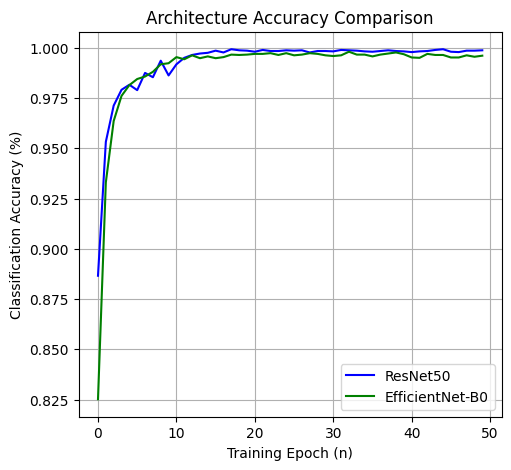

In [ ]:
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(resnet_acc, label='ResNet50', color='blue')
plt.plot(effnet_acc, label='EfficientNet-B0', color='green')
plt.xlabel('Training Epoch (n)') # Full word as per IEEE instructions
plt.ylabel('Classification Accuracy (%)') # Full word and units as per IEEE
plt.title('Architecture Accuracy Comparison')
plt.legend()
plt.grid(True)

# Save following the Bakka rule
plt.savefig('bakka2.png', dpi=300)
plt.show()

## Advanced Medical Evaluation Metrics

=== ResNet50 Classification Report ===
              precision    recall  f1-score   support

      glioma       1.00      0.86      0.93       400
  meningioma       0.91      0.99      0.95       400
     notumor       0.95      1.00      0.98       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.96      1600
   macro avg       0.97      0.96      0.96      1600
weighted avg       0.97      0.96      0.96      1600


=== EfficientNet-B0 Classification Report ===
              precision    recall  f1-score   support

      glioma       1.00      0.83      0.91       400
  meningioma       0.89      0.99      0.94       400
     notumor       0.95      1.00      0.98       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.95      1600
   macro avg       0.96      0.95      0.95      1600
weighted avg       0.96      0.95      0.95      1600



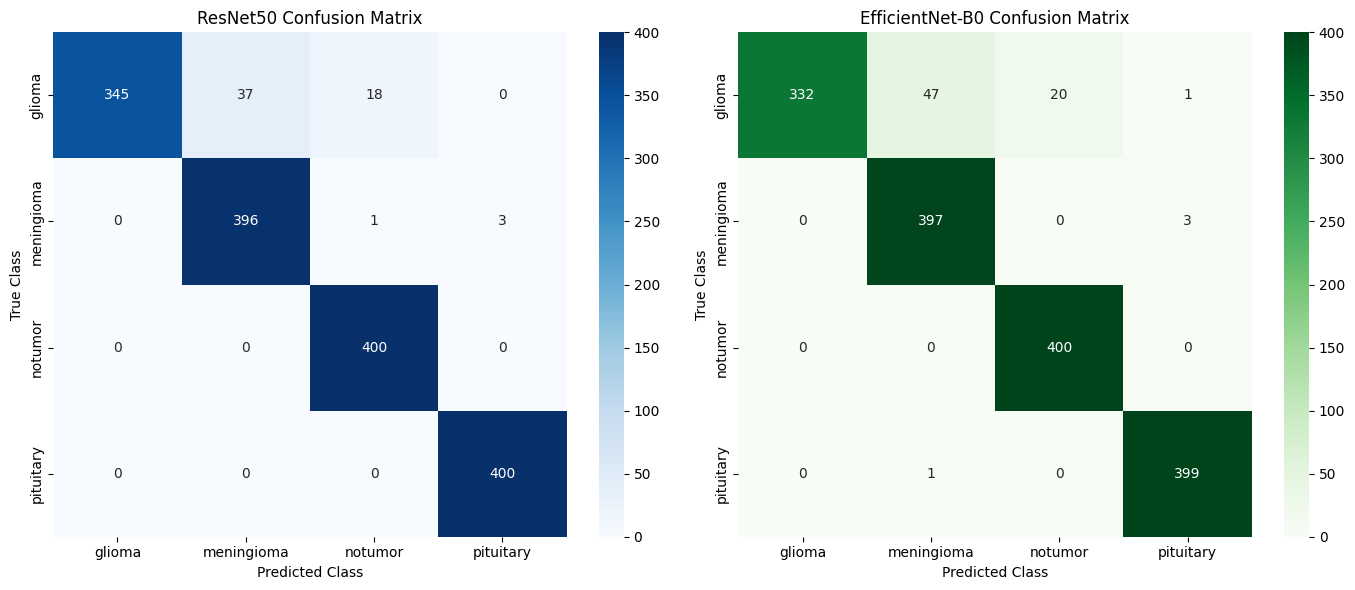

In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

# IEEE Formatting: Set legible font size
plt.rcParams.update({'font.size': 10})

def get_predictions(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Get predictions for both models
true_labels, resnet_preds, resnet_probs = get_predictions(resnet_model, test_loader)
_, effnet_preds, effnet_probs = get_predictions(effnet_model, test_loader)

class_names = test_dataset.classes  # Typically ['glioma', 'meningioma', 'notumor', 'pituitary']

# --- Classification Report ---
print("=== ResNet50 Classification Report ===")
print(classification_report(true_labels, resnet_preds, target_names=class_names))

print("\n=== EfficientNet-B0 Classification Report ===")
print(classification_report(true_labels, effnet_preds, target_names=class_names))

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_resnet = confusion_matrix(true_labels, resnet_preds)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('ResNet50 Confusion Matrix')
axes[0].set_xlabel('Predicted Class')
axes[0].set_ylabel('True Class')

cm_effnet = confusion_matrix(true_labels, effnet_preds)
sns.heatmap(cm_effnet, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('EfficientNet-B0 Confusion Matrix')
axes[1].set_xlabel('Predicted Class')
axes[1].set_ylabel('True Class')

plt.tight_layout()
plt.savefig('bakka3.png', dpi=300)
plt.show()

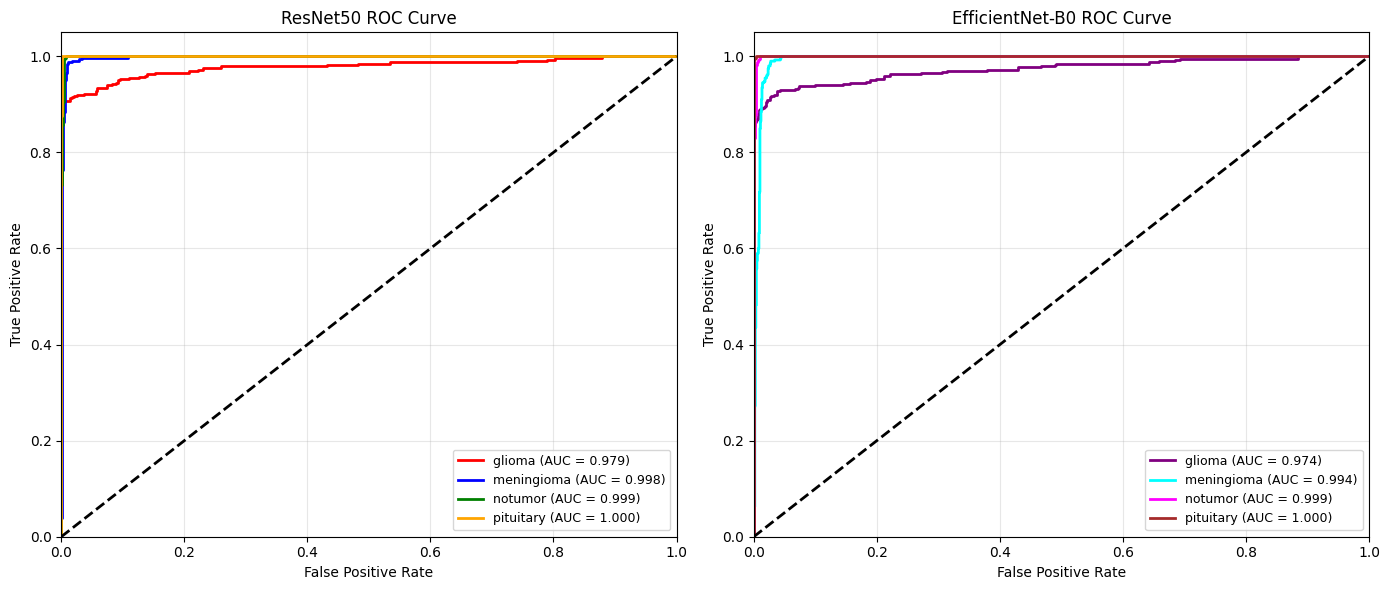

In [8]:
# --- ROC Curves and AUC ---
y_test_binarized = label_binarize(true_labels, classes=[0, 1, 2, 3])
n_classes = y_test_binarized.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_roc(ax, y_true, y_probs, title, colors):
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
        
    ax.plot([0, 1], [0, 1], 'k--', lw=2)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(alpha=0.3)

colors_res = ['red', 'blue', 'green', 'orange']
colors_eff = ['purple', 'cyan', 'magenta', 'brown']

plot_roc(axes[0], y_test_binarized, resnet_probs, 'ResNet50 ROC Curve', colors_res)
plot_roc(axes[1], y_test_binarized, effnet_probs, 'EfficientNet-B0 ROC Curve', colors_eff)

plt.tight_layout()
plt.savefig('bakka5.png', dpi=300)
plt.show()

## Explainability (Grad-CAM)
Visualizing class activation maps to understand model focus areas for the final prediction, ensuring medical reliability.

/tmp/ipykernel_538480/959887483.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  img_unnormalized = torch.tensor(img_tensor).clone()
/home/lorde/projects/Article 1 - Comparative Analysis/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.3960785].


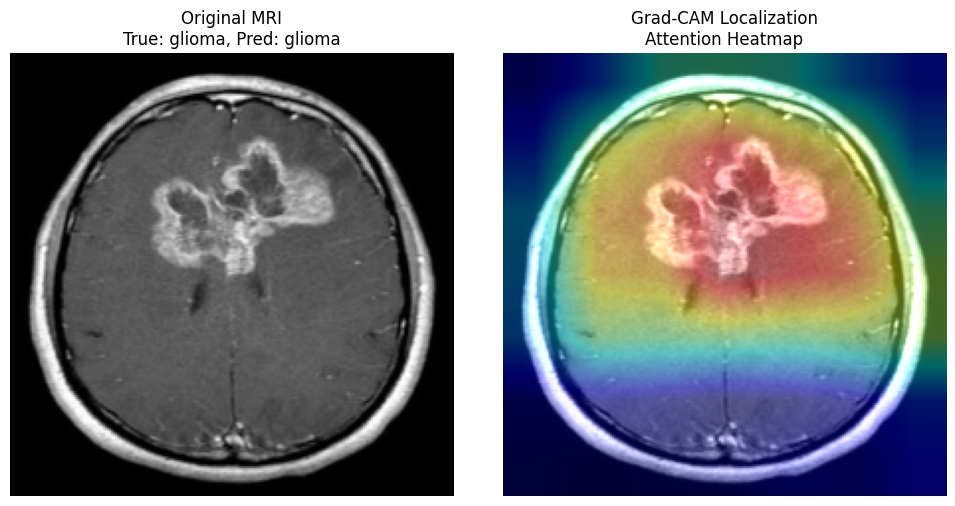

In [9]:
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate(self, x, target_class):
        self.model.eval()
        model_output = self.model(x)
        
        self.model.zero_grad()
        loss = model_output[0, target_class]
        loss.backward()

        gradients = self.gradients.data.cpu().numpy()[0]
        activations = self.activations.data.cpu().numpy()[0]

        weights = np.mean(gradients, axis=(1, 2))
        cam = np.zeros(activations.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (x.shape[2], x.shape[3]))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam

# Select an image from the test set
resnet_model.eval()
img_tensor, true_label = test_dataset[0]  # Let's take the first image
img_unnormalized = torch.tensor(img_tensor).clone()

# Unnormalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_unnormalized = img_unnormalized * std + mean
img_unnormalized = img_unnormalized.numpy().transpose(1, 2, 0)
img_unnormalized = np.clip(img_unnormalized, 0, 1)

img_batch = img_tensor.unsqueeze(0).to(device)

# Initialize Grad-CAM on the last convolutional layer of ResNet50
target_layer = resnet_model.layer4[-1].conv3
grad_cam = GradCAM(resnet_model, target_layer)

output = resnet_model(img_batch)
pred_class = output.argmax(dim=1).item()

cam = grad_cam.generate(img_batch, pred_class)

# Create heatmap
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255
heatmap = heatmap[..., ::-1] # BGR to RGB

# Superimpose heatmap
overlay = heatmap * 0.4 + img_unnormalized

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(img_unnormalized)
axes[0].set_title(f'Original MRI\nTrue: {class_names[true_label]}, Pred: {class_names[pred_class]}')
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title('Grad-CAM Localization\nAttention Heatmap')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('bakka4.png', dpi=300)
plt.show()